<a href="https://colab.research.google.com/github/Boran-Sert/SoftITO_Projler/blob/master/Python/24_09_2026_Ders_i%C3%A7i_Keras_%C3%A7al%C4%B1%C5%9Fmas%C4%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
housing_data = fetch_california_housing(as_frame=True)
df = housing_data.frame
display(df.head(2))

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.02381,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.97188,2401.0,2.109842,37.86,-122.22,3.585


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

X,y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model1 = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
model1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model1.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='mse',
              metrics=['mae'])

In [ ]:

history1 = model1.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=256, verbose=2)

Epoch 1/100
52/52 - 0s - 5ms/step - loss: 0.2569 - mae: 0.3453 - val_loss: 0.2971 - val_mae: 0.3730
Epoch 2/100
52/52 - 0s - 5ms/step - loss: 0.2523 - mae: 0.3440 - val_loss: 0.2952 - val_mae: 0.3681
Epoch 3/100
52/52 - 0s - 5ms/step - loss: 0.2535 - mae: 0.3449 - val_loss: 0.2944 - val_mae: 0.3666
Epoch 4/100
52/52 - 0s - 5ms/step - loss: 0.2530 - mae: 0.3446 - val_loss: 0.2936 - val_mae: 0.3663
Epoch 5/100
52/52 - 0s - 5ms/step - loss: 0.2516 - mae: 0.3438 - val_loss: 0.2933 - val_mae: 0.3657
Epoch 6/100
52/52 - 0s - 5ms/step - loss: 0.2511 - mae: 0.3433 - val_loss: 0.2933 - val_mae: 0.3655
Epoch 7/100
52/52 - 0s - 5ms/step - loss: 0.2512 - mae: 0.3433 - val_loss: 0.2924 - val_mae: 0.3652
Epoch 8/100
52/52 - 0s - 5ms/step - loss: 0.2504 - mae: 0.3427 - val_loss: 0.2922 - val_mae: 0.3663
Epoch 9/100
52/52 - 0s - 5ms/step - loss: 0.2498 - mae: 0.3422 - val_loss: 0.2919 - val_mae: 0.3668
Epoch 10/100
52/52 - 0s - 5ms/step - loss: 0.2496 - mae: 0.3418 - val_loss: 0.2919 - val_mae: 0.3670

In [ ]:

house_age = df['HouseAge'].values
y_class = (house_age > 30).astype(int)


print("Eski ev oranı (1):", np.mean(y_class))
print("Yeni ev oranı (0):", 1 - np.mean(y_class))

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=SEED)


scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c = scaler_c.transform(X_test_c)

Eski ev oranı (1): 0.46002906976744184
Yeni ev oranı (0): 0.5399709302325582


In [ ]:
model2 =keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1,activation="sigmoid"),
])
model2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              loss=keras.losses.BinaryCrossentropy(),
              metrics=[keras.metrics.BinaryAccuracy(name="accuracy")])


In [ ]:

history2 = model2.fit(X_train_c, y_train_c, validation_split=0.2, epochs=100, batch_size=256, verbose=2)

Epoch 1/100
52/52 - 4s - 69ms/step - accuracy: 0.4610 - loss: 26.7196 - val_accuracy: 0.4490 - val_loss: 27.6465
Epoch 2/100
52/52 - 0s - 5ms/step - accuracy: 0.4610 - loss: 26.3458 - val_accuracy: 0.4490 - val_loss: 27.2280
Epoch 3/100
52/52 - 0s - 5ms/step - accuracy: 0.4610 - loss: 25.9447 - val_accuracy: 0.4490 - val_loss: 26.8144
Epoch 4/100
52/52 - 0s - 5ms/step - accuracy: 0.4610 - loss: 25.5463 - val_accuracy: 0.4490 - val_loss: 26.4016
Epoch 5/100
52/52 - 0s - 4ms/step - accuracy: 0.4610 - loss: 25.1476 - val_accuracy: 0.4490 - val_loss: 25.9861
Epoch 6/100
52/52 - 0s - 5ms/step - accuracy: 0.4610 - loss: 24.7427 - val_accuracy: 0.4490 - val_loss: 25.5553
Epoch 7/100
52/52 - 0s - 5ms/step - accuracy: 0.4610 - loss: 24.3213 - val_accuracy: 0.4490 - val_loss: 25.1081
Epoch 8/100
52/52 - 0s - 5ms/step - accuracy: 0.4610 - loss: 23.8816 - val_accuracy: 0.4490 - val_loss: 24.6392
Epoch 9/100
52/52 - 0s - 4ms/step - accuracy: 0.4610 - loss: 23.4263 - val_accuracy: 0.4490 - val_loss:

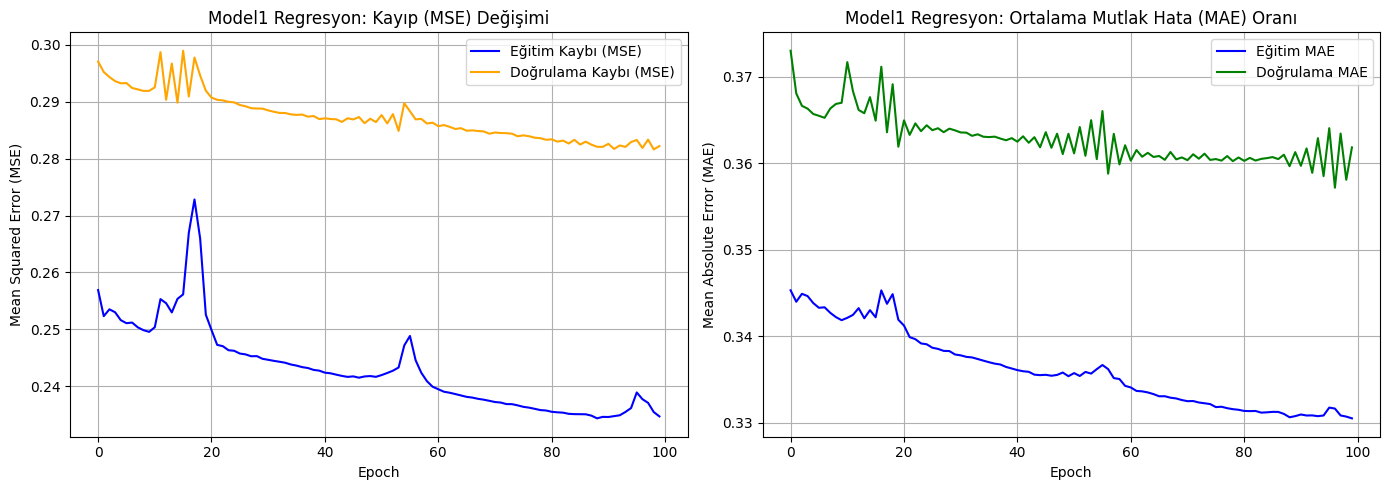

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# 1. Grafik: Kayıp (Loss / MSE) Eğrisi
plt.subplot(1, 2, 1)
plt.plot(history1.history['loss'], label='Eğitim Kaybı (MSE)', color='blue')
plt.plot(history1.history['val_loss'], label='Doğrulama Kaybı (MSE)', color='orange')
plt.title('Model1 Regresyon: Kayıp (MSE) Değişimi')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)

# 2. Grafik: Ortalama Mutlak Hata (MAE) Eğrisi
plt.subplot(1, 2, 2)
plt.plot(history1.history['mae'], label='Eğitim MAE', color='blue')
plt.plot(history1.history['val_mae'], label='Doğrulama MAE', color='green')
plt.title('Model1 Regresyon: Ortalama Mutlak Hata (MAE) Oranı')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

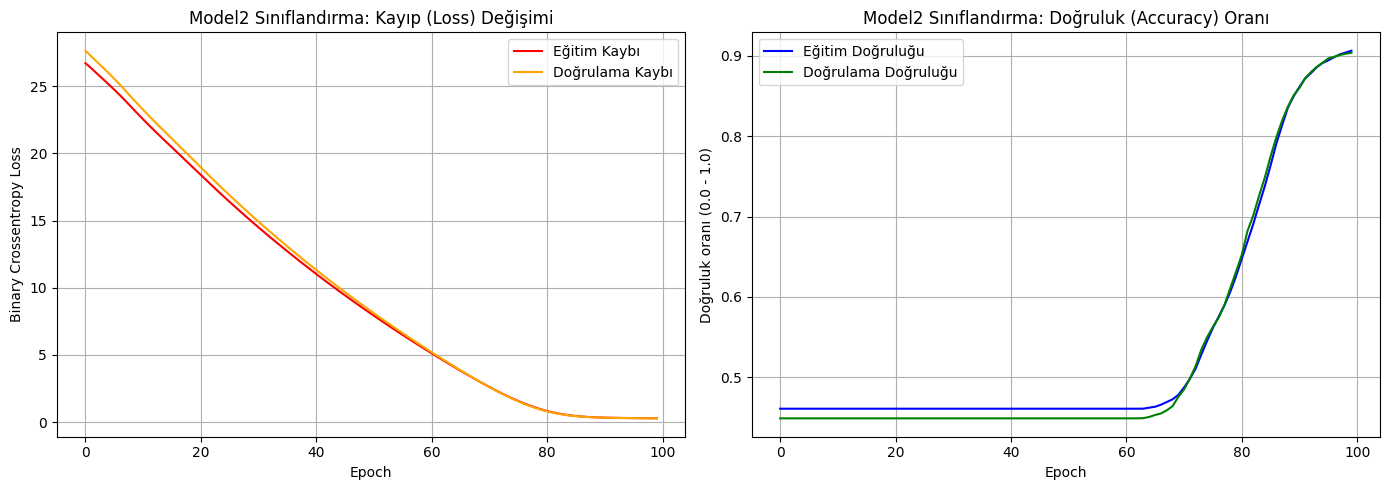

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# 1. Grafik: Kayıp (Loss) Eğrisi
plt.subplot(1, 2, 1)
plt.plot(history2.history['loss'], label='Eğitim Kaybı', color='red')
plt.plot(history2.history['val_loss'], label='Doğrulama Kaybı', color='orange')
plt.title('Model2 Sınıflandırma: Kayıp (Loss) Değişimi')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.grid(True)

# 2. Grafik: Doğruluk (Accuracy) Eğrisi
plt.subplot(1, 2, 2)
plt.plot(history2.history['accuracy'], label='Eğitim Doğruluğu', color='blue')
plt.plot(history2.history['val_accuracy'], label='Doğrulama Doğruluğu', color='green')
plt.title('Model2 Sınıflandırma: Doğruluk (Accuracy) Oranı')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk oranı (0.0 - 1.0)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()